In [18]:
from pathlib import Path
import sys

# If notebook is inside notebooks/, project root is one level above
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
from pathlib import Path

PLOT_DIR = Path("../reports/final_rf_tree_baseline/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

Project root: c:\Users\Hp\OneDrive\Desktop\vehicle-predictive-maintenance


In [19]:

import pandas as pd
import matplotlib.pyplot as plt

from src.config import PROCESSED_DIR

clean_results = pd.read_csv(PROCESSED_DIR / "all_datasets_clean_cal_to_eval_summary.csv")

clean_results

,dataset,cost_fn,cost_fp,best_k_chosen_on_calibration,point_eval_FP,point_eval_FN,point_eval_false_negative_rate,point_eval_false_positive_rate,point_eval_total_cost,uncertainty_eval_FP,uncertainty_eval_FN,uncertainty_eval_false_negative_rate,uncertainty_eval_false_positive_rate,uncertainty_eval_total_cost,cost_reduction_percent,fn_reduction_percent,cal_FP,cal_FN,cal_total_cost
0,FD001,2,1.0,0.05,44.0,61.0,0.145238,0.011876,166.0,47.0,57.0,0.135714,0.012686,161.0,3.012048,6.557377,63.0,48.0,159.0
1,FD001,5,1.0,0.65,44.0,61.0,0.145238,0.011876,349.0,125.0,26.0,0.061905,0.033738,255.0,26.934097,57.377049,154.0,19.0,249.0
2,FD001,10,1.0,1.05,44.0,61.0,0.145238,0.011876,654.0,230.0,9.0,0.021429,0.062078,320.0,51.070336,85.245902,267.0,4.0,307.0
3,FD001,20,1.0,1.05,44.0,61.0,0.145238,0.011876,1264.0,230.0,9.0,0.021429,0.062078,410.0,67.563291,85.245902,267.0,4.0,347.0
4,FD001,50,1.0,1.35,44.0,61.0,0.145238,0.011876,3094.0,394.0,2.0,0.004762,0.106343,494.0,84.033613,96.721311,416.0,0.0,416.0
5,FD001,100,1.0,1.35,44.0,61.0,0.145238,0.011876,6144.0,394.0,2.0,0.004762,0.106343,594.0,90.332031,96.721311,416.0,0.0,416.0
6,FD002,2,1.0,0.75,113.0,618.0,0.565934,0.012012,1349.0,517.0,290.0,0.265568,0.054959,1097.0,18.680504,53.074434,493.0,265.0,1023.0
7,FD002,5,1.0,1.00,113.0,618.0,0.565934,0.012012,3203.0,853.0,177.0,0.162088,0.090677,1738.0,45.738370,71.359223,769.0,160.0,1569.0
8,FD002,10,1.0,1.25,113.0,618.0,0.565934,0.012012,6293.0,1297.0,107.0,0.097985,0.137876,2367.0,62.386779,82.686084,1174.0,96.0,2134.0
9,FD002,20,1.0,1.55,113.0,618.0,0.565934,0.012012,12473.0,1925.0,53.0,0.048535,0.204635,2985.0,76.068308,91.423948,1811.0,50.0,2811.0


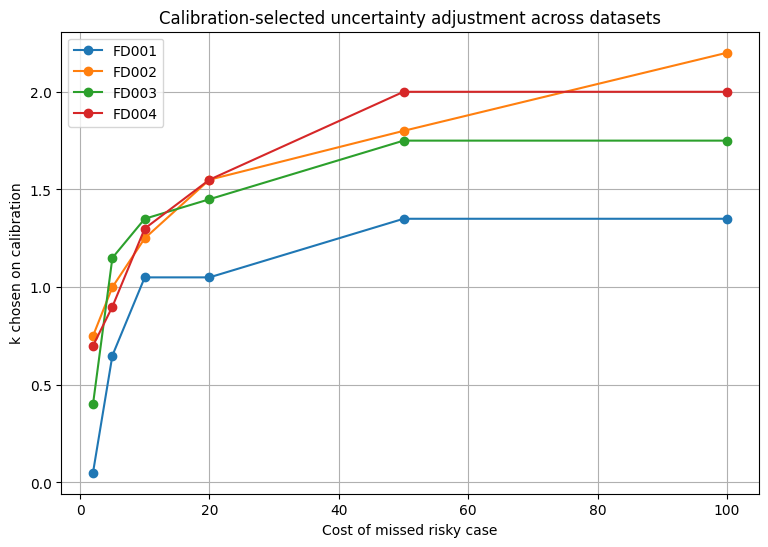

In [20]:
plt.figure(figsize=(9, 6))

for dataset in clean_results["dataset"].unique():
    subset = clean_results[clean_results["dataset"] == dataset]
    plt.plot(
        subset["cost_fn"],
        subset["best_k_chosen_on_calibration"],
        marker="o",
        label=dataset,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("k chosen on calibration")
plt.title("Calibration-selected uncertainty adjustment across datasets")
plt.legend()
plt.grid(True)
plt.show()

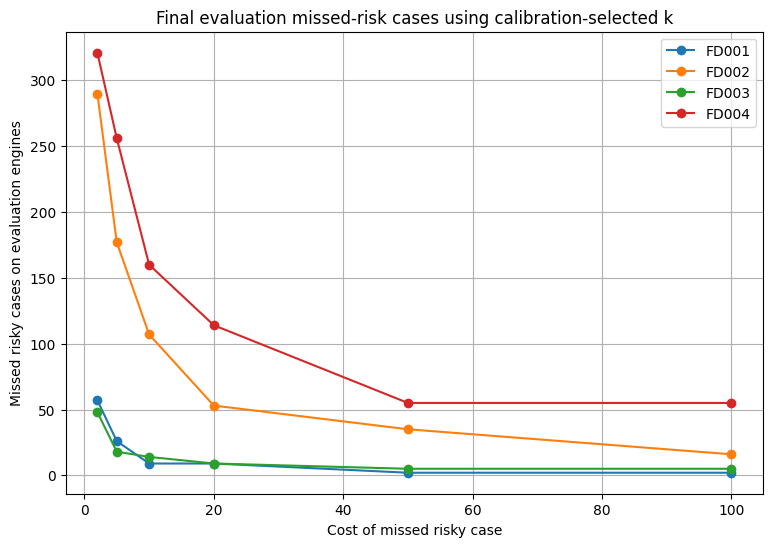

In [21]:
plt.figure(figsize=(9, 6))

for dataset in clean_results["dataset"].unique():
    subset = clean_results[clean_results["dataset"] == dataset]
    plt.plot(
        subset["cost_fn"],
        subset["uncertainty_eval_FN"],
        marker="o",
        label=dataset,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Missed risky cases on evaluation engines")
plt.title("Final evaluation missed-risk cases using calibration-selected k")
plt.legend()
plt.grid(True)
plt.show()

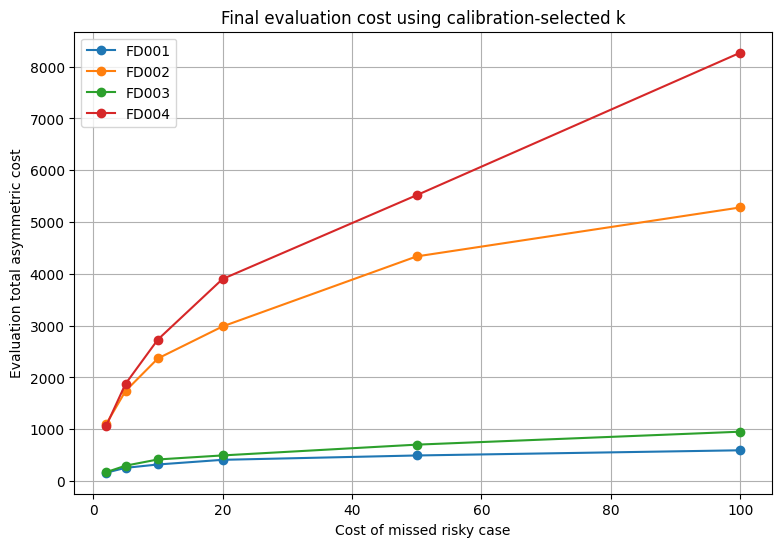

In [22]:
plt.figure(figsize=(9, 6))

for dataset in clean_results["dataset"].unique():
    subset = clean_results[clean_results["dataset"] == dataset]
    plt.plot(
        subset["cost_fn"],
        subset["uncertainty_eval_total_cost"],
        marker="o",
        label=dataset,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Evaluation total asymmetric cost")
plt.title("Final evaluation cost using calibration-selected k")
plt.legend()
plt.grid(True)
plt.show()

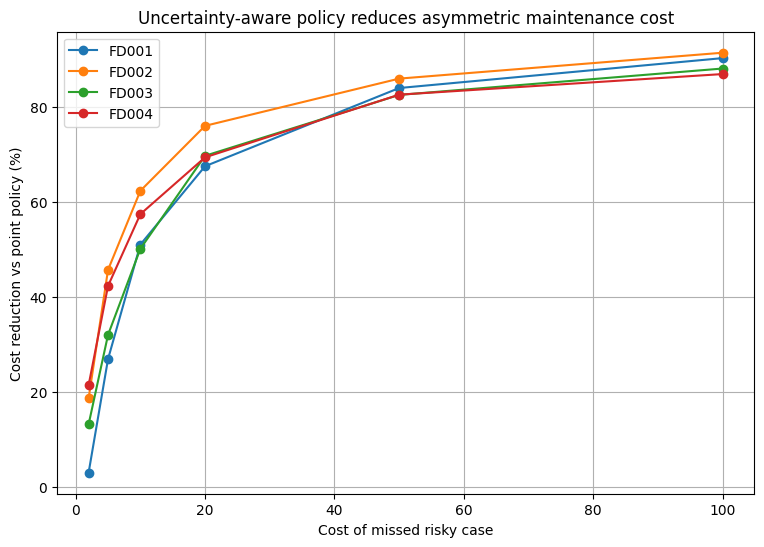

In [23]:
plt.figure(figsize=(9, 6))

for dataset in clean_results["dataset"].unique():
    subset = clean_results[clean_results["dataset"] == dataset]
    plt.plot(
        subset["cost_fn"],
        subset["cost_reduction_percent"],
        marker="o",
        label=dataset,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Cost reduction vs point policy (%)")
plt.title("Uncertainty-aware policy reduces asymmetric maintenance cost")
plt.legend()
plt.grid(True)

plt.savefig(PLOT_DIR / "rf_tree_cost_reduction_vs_point_policy.png", dpi=300, bbox_inches="tight")
plt.show()

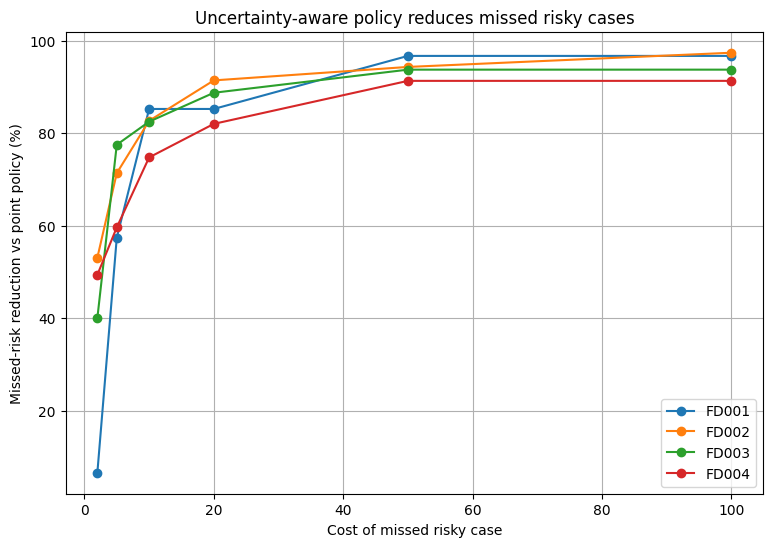

In [24]:
plt.figure(figsize=(9, 6))

for dataset in clean_results["dataset"].unique():
    subset = clean_results[clean_results["dataset"] == dataset]
    plt.plot(
        subset["cost_fn"],
        subset["fn_reduction_percent"],
        marker="o",
        label=dataset,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Missed-risk reduction vs point policy (%)")
plt.title("Uncertainty-aware policy reduces missed risky cases")
plt.legend()
plt.grid(True)

plt.savefig(PLOT_DIR / "rf_tree_missed_risk_reduction_vs_point_policy.png", dpi=300, bbox_inches="tight")
plt.show()

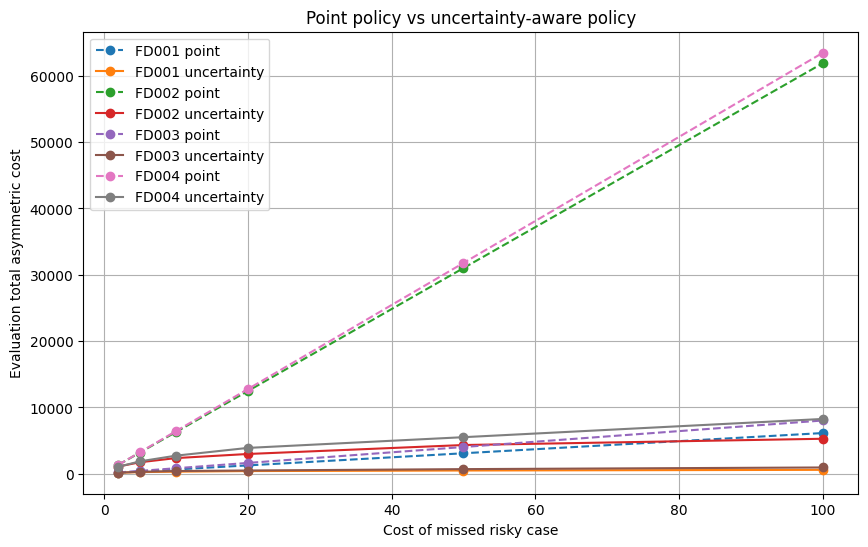

In [25]:
plt.figure(figsize=(10, 6))

for dataset in clean_results["dataset"].unique():
    subset = clean_results[clean_results["dataset"] == dataset]

    plt.plot(
        subset["cost_fn"],
        subset["point_eval_total_cost"],
        marker="o",
        linestyle="--",
        label=f"{dataset} point",
    )

    plt.plot(
        subset["cost_fn"],
        subset["uncertainty_eval_total_cost"],
        marker="o",
        linestyle="-",
        label=f"{dataset} uncertainty",
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Evaluation total asymmetric cost")
plt.title("Point policy vs uncertainty-aware policy")
plt.legend()
plt.grid(True)

plt.savefig(PLOT_DIR / "rf_tree_point_vs_uncertainty_cost.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:


rf_results = pd.read_csv(PROCESSED_DIR / "all_datasets_clean_cal_to_eval_summary.csv")
rf_fd001 = rf_results[rf_results["dataset"] == "FD001"].copy()
rf_fd001["method"] = "rf_tree_std"

bootstrap_fd001 = pd.read_csv(
    PROCESSED_DIR / "fd001_bootstrap_gbr_clean_cal_to_eval_summary.csv"
)

compare_fd001 = pd.concat(
    [
        rf_fd001,
        bootstrap_fd001,
    ],
    ignore_index=True,
)

compare_fd001[
    [
        "dataset",
        "method",
        "cost_fn",
        "best_k_chosen_on_calibration",
        "point_eval_FN",
        "uncertainty_eval_FN",
        "fn_reduction_percent",
        "point_eval_total_cost",
        "uncertainty_eval_total_cost",
        "cost_reduction_percent",
    ]
]

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
0,FD001,rf_tree_std,2,0.05,61.0,57.0,6.557377,166.0,161.0,3.012048
1,FD001,rf_tree_std,5,0.65,61.0,26.0,57.377049,349.0,255.0,26.934097
2,FD001,rf_tree_std,10,1.05,61.0,9.0,85.245902,654.0,320.0,51.070336
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
4,FD001,rf_tree_std,50,1.35,61.0,2.0,96.721311,3094.0,494.0,84.033613
5,FD001,rf_tree_std,100,1.35,61.0,2.0,96.721311,6144.0,594.0,90.332031
6,FD001,bootstrap_gbr,2,0.40,68.0,56.0,17.647059,183.0,171.0,6.557377
7,FD001,bootstrap_gbr,5,1.50,68.0,38.0,44.117647,387.0,278.0,28.165375
8,FD001,bootstrap_gbr,10,2.20,68.0,28.0,58.823529,727.0,398.0,45.254470
9,FD001,bootstrap_gbr,20,2.60,68.0,21.0,69.117647,1407.0,573.0,59.275053


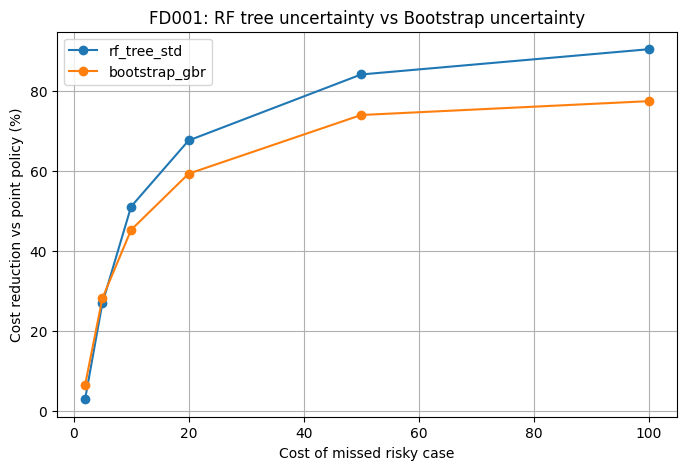

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for method in compare_fd001["method"].unique():
    subset = compare_fd001[compare_fd001["method"] == method]
    plt.plot(
        subset["cost_fn"],
        subset["cost_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Cost reduction vs point policy (%)")
plt.title("FD001: RF tree uncertainty vs Bootstrap uncertainty")
plt.legend()
plt.grid(True)
plt.show()

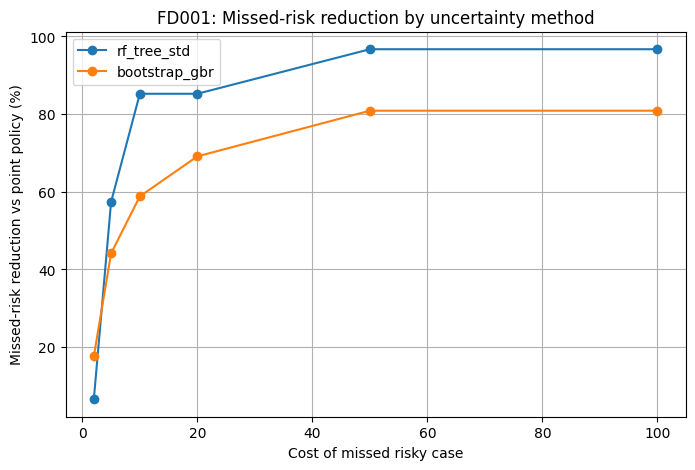

In [28]:
plt.figure(figsize=(8, 5))

for method in compare_fd001["method"].unique():
    subset = compare_fd001[compare_fd001["method"] == method]
    plt.plot(
        subset["cost_fn"],
        subset["fn_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Missed-risk reduction vs point policy (%)")
plt.title("FD001: Missed-risk reduction by uncertainty method")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DIR

rf_results = pd.read_csv(PROCESSED_DIR / "all_datasets_clean_cal_to_eval_summary.csv")
rf_results["method"] = "rf_tree_std"

bootstrap_gbr_results = pd.read_csv(
    PROCESSED_DIR / "all_datasets_bootstrap_gbr_clean_cal_to_eval_summary.csv"
)

method_compare = pd.concat(
    [
        rf_results,
        bootstrap_gbr_results,
    ],
    ignore_index=True,
)

method_compare[
    [
        "dataset",
        "method",
        "cost_fn",
        "best_k_chosen_on_calibration",
        "point_eval_FN",
        "uncertainty_eval_FN",
        "fn_reduction_percent",
        "point_eval_total_cost",
        "uncertainty_eval_total_cost",
        "cost_reduction_percent",
    ]
]


,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
0,FD001,rf_tree_std,2,0.05,61.0,57.0,6.557377,166.0,161.0,3.012048
1,FD001,rf_tree_std,5,0.65,61.0,26.0,57.377049,349.0,255.0,26.934097
2,FD001,rf_tree_std,10,1.05,61.0,9.0,85.245902,654.0,320.0,51.070336
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
4,FD001,rf_tree_std,50,1.35,61.0,2.0,96.721311,3094.0,494.0,84.033613
5,FD001,rf_tree_std,100,1.35,61.0,2.0,96.721311,6144.0,594.0,90.332031
6,FD002,rf_tree_std,2,0.75,618.0,290.0,53.074434,1349.0,1097.0,18.680504
7,FD002,rf_tree_std,5,1.00,618.0,177.0,71.359223,3203.0,1738.0,45.738370
8,FD002,rf_tree_std,10,1.25,618.0,107.0,82.686084,6293.0,2367.0,62.386779
9,FD002,rf_tree_std,20,1.55,618.0,53.0,91.423948,12473.0,2985.0,76.068308


In [31]:
METHOD_COMPARE_DIR = PROJECT_ROOT / "reports" / "method_comparison"
METHOD_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

method_compare_table = method_compare[
    [
        "dataset",
        "method",
        "cost_fn",
        "best_k_chosen_on_calibration",
        "point_eval_FN",
        "uncertainty_eval_FN",
        "fn_reduction_percent",
        "point_eval_total_cost",
        "uncertainty_eval_total_cost",
        "cost_reduction_percent",
    ]
].copy()

method_compare_table.to_csv(
    METHOD_COMPARE_DIR / "rf_tree_vs_bootstrap_gbr_all_datasets.csv",
    index=False,
)

method_compare_table

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
0,FD001,rf_tree_std,2,0.05,61.0,57.0,6.557377,166.0,161.0,3.012048
1,FD001,rf_tree_std,5,0.65,61.0,26.0,57.377049,349.0,255.0,26.934097
2,FD001,rf_tree_std,10,1.05,61.0,9.0,85.245902,654.0,320.0,51.070336
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
4,FD001,rf_tree_std,50,1.35,61.0,2.0,96.721311,3094.0,494.0,84.033613
5,FD001,rf_tree_std,100,1.35,61.0,2.0,96.721311,6144.0,594.0,90.332031
6,FD002,rf_tree_std,2,0.75,618.0,290.0,53.074434,1349.0,1097.0,18.680504
7,FD002,rf_tree_std,5,1.00,618.0,177.0,71.359223,3203.0,1738.0,45.738370
8,FD002,rf_tree_std,10,1.25,618.0,107.0,82.686084,6293.0,2367.0,62.386779
9,FD002,rf_tree_std,20,1.55,618.0,53.0,91.423948,12473.0,2985.0,76.068308


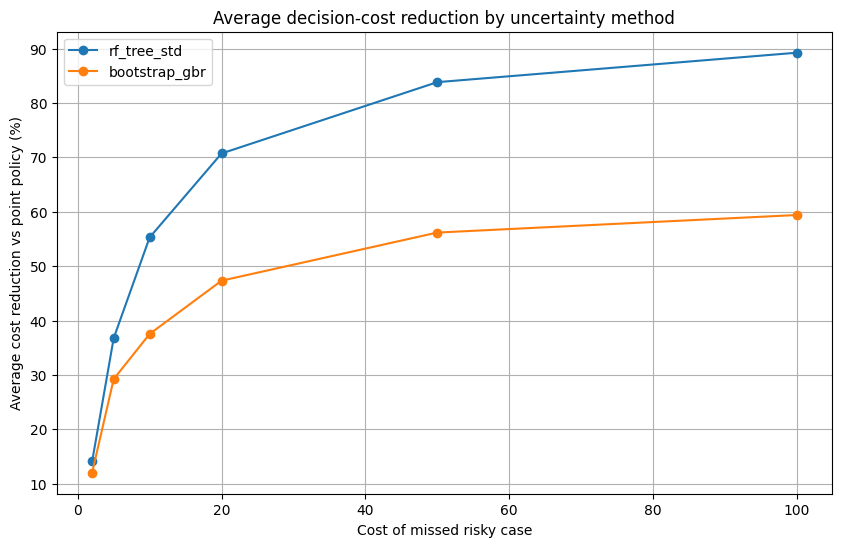

In [32]:
plt.figure(figsize=(10, 6))

for method in method_compare["method"].unique():
    subset = (
        method_compare[method_compare["method"] == method]
        .groupby("cost_fn")["cost_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["cost_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average cost reduction vs point policy (%)")
plt.title("Average decision-cost reduction by uncertainty method")
plt.legend()
plt.grid(True)

plt.savefig(METHOD_COMPARE_DIR / "avg_cost_reduction_rf_tree_vs_bootstrap_gbr.png", dpi=300, bbox_inches="tight")
plt.show()

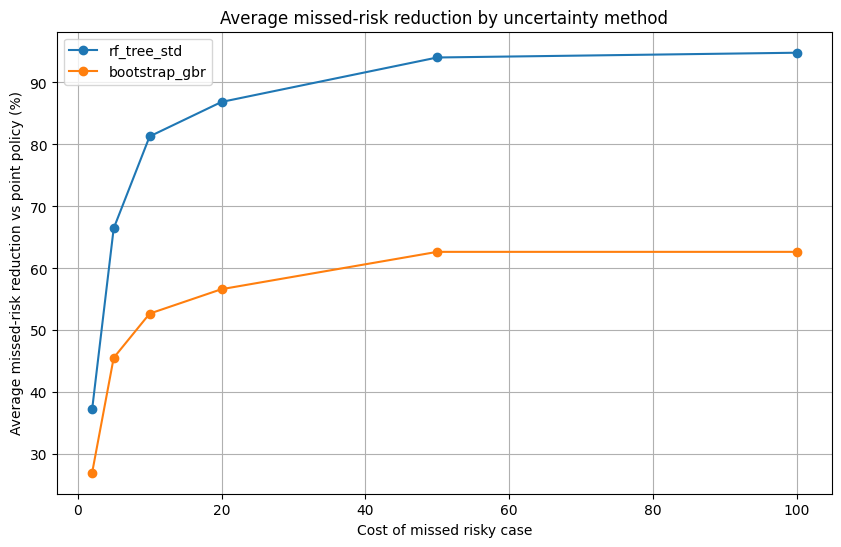

In [33]:
plt.figure(figsize=(10, 6))

for method in method_compare["method"].unique():
    subset = (
        method_compare[method_compare["method"] == method]
        .groupby("cost_fn")["fn_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["fn_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average missed-risk reduction vs point policy (%)")
plt.title("Average missed-risk reduction by uncertainty method")
plt.legend()
plt.grid(True)

plt.savefig(METHOD_COMPARE_DIR / "avg_fn_reduction_rf_tree_vs_bootstrap_gbr.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
cost_20_compare = method_compare_table[
    method_compare_table["cost_fn"] == 20
].sort_values(["dataset", "method"])

cost_20_compare.to_csv(
    METHOD_COMPARE_DIR / "cost_fn_20_method_comparison.csv",
    index=False,
)

cost_20_compare

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
27,FD001,bootstrap_gbr,20,2.60,68.0,21.0,69.117647,1407.0,573.0,59.275053
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
33,FD002,bootstrap_gbr,20,6.00,895.0,603.0,32.625698,17971.0,12460.0,30.666073
9,FD002,rf_tree_std,20,1.55,618.0,53.0,91.423948,12473.0,2985.0,76.068308
39,FD003,bootstrap_gbr,20,3.65,73.0,11.0,84.931507,1521.0,582.0,61.735700
15,FD003,rf_tree_std,20,1.45,80.0,9.0,88.750000,1637.0,495.0,69.761759
45,FD004,bootstrap_gbr,20,6.00,882.0,530.0,39.909297,17686.0,11036.0,37.600362
21,FD004,rf_tree_std,20,1.55,634.0,114.0,82.018927,12764.0,3901.0,69.437480


In [37]:
bootstrap_rf_results = pd.read_csv(
    PROCESSED_DIR / "all_datasets_bootstrap_rf_clean_cal_to_eval_summary.csv"
)

all_three_methods = pd.concat(
    [
        rf_results,
        bootstrap_gbr_results,
        bootstrap_rf_results,
    ],
    ignore_index=True,
)

all_three_table = all_three_methods[
    [
        "dataset",
        "method",
        "cost_fn",
        "best_k_chosen_on_calibration",
        "point_eval_FN",
        "uncertainty_eval_FN",
        "fn_reduction_percent",
        "point_eval_total_cost",
        "uncertainty_eval_total_cost",
        "cost_reduction_percent",
    ]
].copy()

all_three_table.to_csv(
    METHOD_COMPARE_DIR / "rf_tree_vs_bootstrap_gbr_vs_bootstrap_rf.csv",
    index=False,
)

all_three_table

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
0,FD001,rf_tree_std,2,0.05,61.0,57.0,6.557377,166.0,161.0,3.012048
1,FD001,rf_tree_std,5,0.65,61.0,26.0,57.377049,349.0,255.0,26.934097
2,FD001,rf_tree_std,10,1.05,61.0,9.0,85.245902,654.0,320.0,51.070336
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
4,FD001,rf_tree_std,50,1.35,61.0,2.0,96.721311,3094.0,494.0,84.033613
...,...,...,...,...,...,...,...,...,...,...
67,FD004,bootstrap_rf,5,3.65,635.0,251.0,60.472441,3255.0,1926.0,40.829493
68,FD004,bootstrap_rf,10,5.20,635.0,165.0,74.015748,6430.0,2840.0,55.832037
69,FD004,bootstrap_rf,20,5.95,635.0,134.0,78.897638,12780.0,4178.0,67.308294
70,FD004,bootstrap_rf,50,5.95,635.0,134.0,78.897638,31830.0,8198.0,74.244423


In [38]:
boundary_check = all_three_table[
    all_three_table["best_k_chosen_on_calibration"] >= 5.95
][
    [
        "dataset",
        "method",
        "cost_fn",
        "best_k_chosen_on_calibration",
        "fn_reduction_percent",
        "cost_reduction_percent",
    ]
]

boundary_check

,dataset,method,cost_fn,best_k_chosen_on_calibration,fn_reduction_percent,cost_reduction_percent
30,FD002,bootstrap_gbr,2,5.95,32.513966,13.970983
31,FD002,bootstrap_gbr,5,5.95,32.513966,24.923009
32,FD002,bootstrap_gbr,10,6.00,32.625698,28.721871
33,FD002,bootstrap_gbr,20,6.00,32.625698,30.666073
34,FD002,bootstrap_gbr,50,6.00,32.625698,31.839986
35,FD002,bootstrap_gbr,100,6.00,32.625698,32.232531
43,FD004,bootstrap_gbr,5,6.00,39.909297,30.745063
44,FD004,bootstrap_gbr,10,6.00,39.909297,35.303406
45,FD004,bootstrap_gbr,20,6.00,39.909297,37.600362
46,FD004,bootstrap_gbr,50,6.00,39.909297,38.984279


In [39]:
avg_method_summary = (
    all_three_table
    .groupby(["method", "cost_fn"])
    .agg(
        avg_cost_reduction_percent=("cost_reduction_percent", "mean"),
        avg_fn_reduction_percent=("fn_reduction_percent", "mean"),
        avg_best_k=("best_k_chosen_on_calibration", "mean"),
    )
    .reset_index()
)

avg_method_summary

,method,cost_fn,avg_cost_reduction_percent,avg_fn_reduction_percent,avg_best_k
0,bootstrap_gbr,2,12.019151,27.028654,3.1125
1,bootstrap_gbr,5,29.233010,45.573584,3.8250
2,bootstrap_gbr,10,37.528534,52.702645,4.3750
3,bootstrap_gbr,20,47.319297,56.646037,4.5625
4,bootstrap_gbr,50,56.167041,62.669406,5.2500
5,bootstrap_gbr,100,59.394153,62.669406,5.2500
6,bootstrap_rf,2,13.062583,27.922012,1.3250
7,bootstrap_rf,5,34.636575,59.962027,2.9875
8,bootstrap_rf,10,51.405838,70.416901,3.8750
9,bootstrap_rf,20,64.327602,81.194787,4.7625


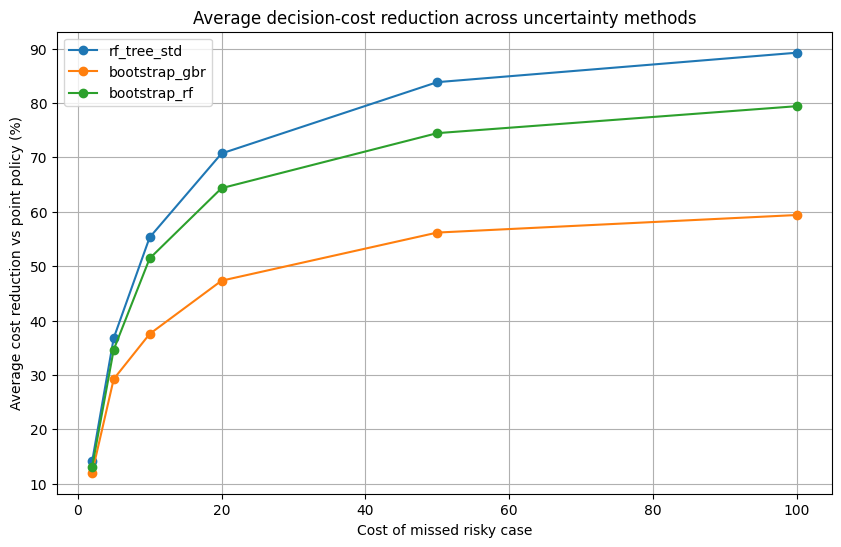

In [40]:
plt.figure(figsize=(10, 6))

for method in all_three_methods["method"].unique():
    subset = (
        all_three_methods[all_three_methods["method"] == method]
        .groupby("cost_fn")["cost_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["cost_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average cost reduction vs point policy (%)")
plt.title("Average decision-cost reduction across uncertainty methods")
plt.legend()
plt.grid(True)

plt.savefig(METHOD_COMPARE_DIR / "avg_cost_reduction_all_three_methods.png", dpi=300, bbox_inches="tight")
plt.show()

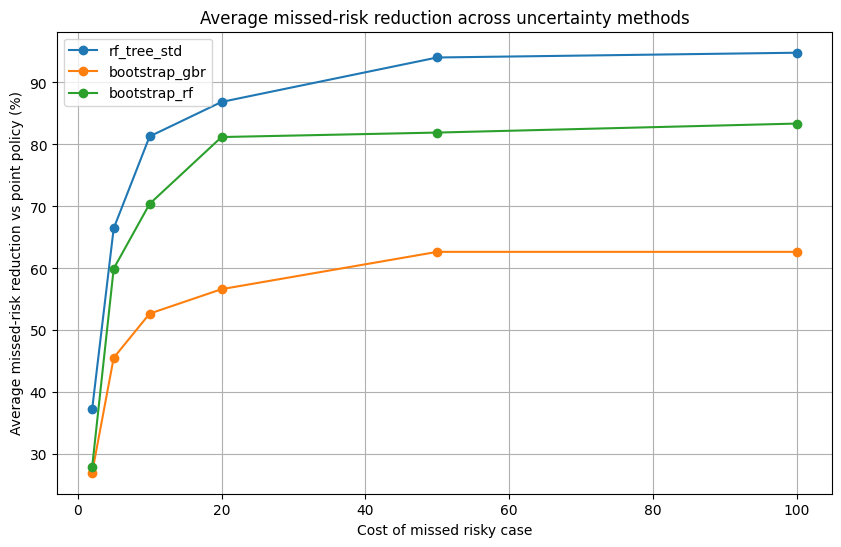

In [41]:
plt.figure(figsize=(10, 6))

for method in all_three_methods["method"].unique():
    subset = (
        all_three_methods[all_three_methods["method"] == method]
        .groupby("cost_fn")["fn_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["fn_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average missed-risk reduction vs point policy (%)")
plt.title("Average missed-risk reduction across uncertainty methods")
plt.legend()
plt.grid(True)

plt.savefig(METHOD_COMPARE_DIR / "avg_fn_reduction_all_three_methods.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
cost_20_all_methods = all_three_table[
    all_three_table["cost_fn"] == 20
].sort_values(["dataset", "method"])

cost_20_all_methods.to_csv(
    METHOD_COMPARE_DIR / "cost_fn_20_all_methods_k0_to_6.csv",
    index=False,
)

cost_20_all_methods

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
27,FD001,bootstrap_gbr,20,2.60,68.0,21.0,69.117647,1407.0,573.0,59.275053
51,FD001,bootstrap_rf,20,3.60,58.0,13.0,77.586207,1204.0,588.0,51.162791
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
33,FD002,bootstrap_gbr,20,6.00,895.0,603.0,32.625698,17971.0,12460.0,30.666073
57,FD002,bootstrap_rf,20,6.00,639.0,106.0,83.411581,12875.0,3741.0,70.943689
9,FD002,rf_tree_std,20,1.55,618.0,53.0,91.423948,12473.0,2985.0,76.068308
39,FD003,bootstrap_gbr,20,3.65,73.0,11.0,84.931507,1521.0,582.0,61.735700
63,FD003,bootstrap_rf,20,3.50,86.0,13.0,84.883721,1763.0,566.0,67.895632
15,FD003,rf_tree_std,20,1.45,80.0,9.0,88.750000,1637.0,495.0,69.761759
45,FD004,bootstrap_gbr,20,6.00,882.0,530.0,39.909297,17686.0,11036.0,37.600362


In [43]:
all_three_table.to_csv(
    METHOD_COMPARE_DIR / "rf_tree_vs_bootstrap_gbr_vs_bootstrap_rf_k0_to_6.csv",
    index=False,
)

avg_method_summary.to_csv(
    METHOD_COMPARE_DIR / "average_method_summary_k0_to_6.csv",
    index=False,
)

In [44]:
quantile_results = pd.read_csv(
    PROCESSED_DIR / "all_datasets_quantile_gbr_clean_cal_to_eval_summary.csv"
)

all_methods_plus_quantile = pd.concat(
    [
        all_three_methods,
        quantile_results,
    ],
    ignore_index=True,
)

all_methods_plus_quantile_table = all_methods_plus_quantile[
    [
        "dataset",
        "method",
        "cost_fn",
        "best_k_chosen_on_calibration",
        "point_eval_FN",
        "uncertainty_eval_FN",
        "fn_reduction_percent",
        "point_eval_total_cost",
        "uncertainty_eval_total_cost",
        "cost_reduction_percent",
    ]
].copy()

all_methods_plus_quantile_table

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
0,FD001,rf_tree_std,2,0.05,61.0,57.0,6.557377,166.0,161.0,3.012048
1,FD001,rf_tree_std,5,0.65,61.0,26.0,57.377049,349.0,255.0,26.934097
2,FD001,rf_tree_std,10,1.05,61.0,9.0,85.245902,654.0,320.0,51.070336
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
4,FD001,rf_tree_std,50,1.35,61.0,2.0,96.721311,3094.0,494.0,84.033613
...,...,...,...,...,...,...,...,...,...,...
91,FD004,quantile_gbr,5,1.10,844.0,272.0,67.772512,4286.0,2128.0,50.349977
92,FD004,quantile_gbr,10,1.20,844.0,173.0,79.502370,8506.0,3019.0,64.507407
93,FD004,quantile_gbr,20,1.25,844.0,116.0,86.255924,16946.0,4020.0,76.277588
94,FD004,quantile_gbr,50,1.30,844.0,62.0,92.654028,42266.0,5672.0,86.580230


In [45]:
all_methods_plus_quantile_table.to_csv(
    METHOD_COMPARE_DIR / "all_methods_plus_quantile_comparison.csv",
    index=False,
)

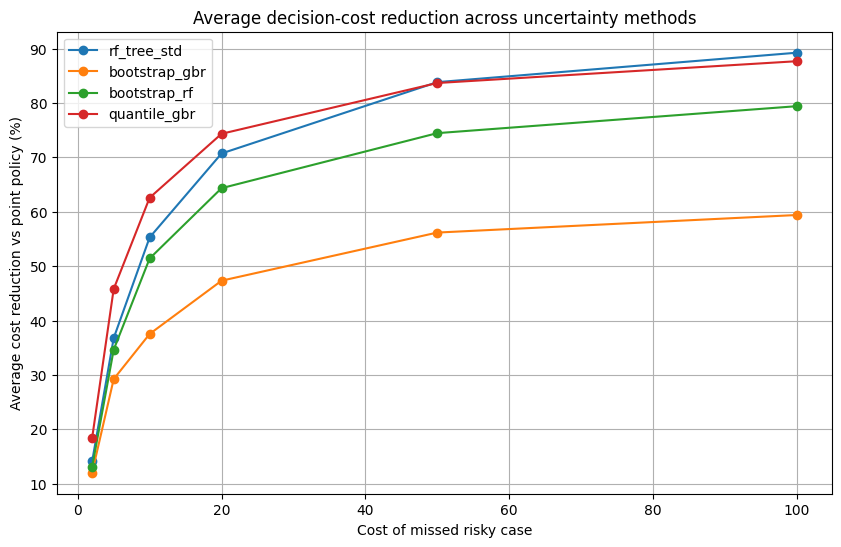

In [46]:
plt.figure(figsize=(10, 6))

for method in all_methods_plus_quantile["method"].unique():
    subset = (
        all_methods_plus_quantile[all_methods_plus_quantile["method"] == method]
        .groupby("cost_fn")["cost_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["cost_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average cost reduction vs point policy (%)")
plt.title("Average decision-cost reduction across uncertainty methods")
plt.legend()
plt.grid(True)

plt.savefig(METHOD_COMPARE_DIR / "avg_cost_reduction_with_quantile.png", dpi=300, bbox_inches="tight")
plt.show()

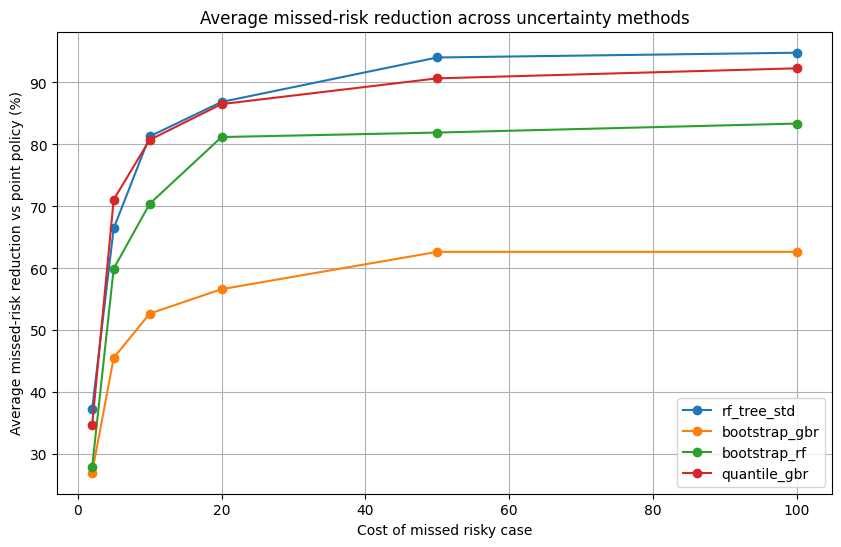

In [47]:
plt.figure(figsize=(10, 6))

for method in all_methods_plus_quantile["method"].unique():
    subset = (
        all_methods_plus_quantile[all_methods_plus_quantile["method"] == method]
        .groupby("cost_fn")["fn_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["fn_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average missed-risk reduction vs point policy (%)")
plt.title("Average missed-risk reduction across uncertainty methods")
plt.legend()
plt.grid(True)

plt.savefig(METHOD_COMPARE_DIR / "avg_fn_reduction_with_quantile.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
quantile_interval_quality = pd.read_csv(
    PROCESSED_DIR / "all_datasets_quantile_gbr_interval_quality.csv"
)

quantile_interval_quality

,dataset,method,coverage,mean_interval_width,median_interval_width,mean_abs_error
0,FD001,quantile_gbr,0.778424,48.830015,49.314755,16.905150
1,FD002,quantile_gbr,0.868654,92.326450,94.881515,28.027027
2,FD003,quantile_gbr,0.810675,47.101830,44.654952,14.747086
3,FD004,quantile_gbr,0.853818,83.598510,84.403951,30.347928


In [49]:
# Part 2 — Make final comparison table

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DIR

METHOD_COMPARE_DIR = PROJECT_ROOT / "reports" / "method_comparison"
METHOD_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

rf_results = pd.read_csv(PROCESSED_DIR / "all_datasets_clean_cal_to_eval_summary.csv")
rf_results["method"] = "rf_tree_std"

bootstrap_gbr_results = pd.read_csv(
    PROCESSED_DIR / "all_datasets_bootstrap_gbr_clean_cal_to_eval_summary.csv"
)

bootstrap_rf_results = pd.read_csv(
    PROCESSED_DIR / "all_datasets_bootstrap_rf_clean_cal_to_eval_summary.csv"
)

quantile_results = pd.read_csv(
    PROCESSED_DIR / "all_datasets_quantile_gbr_clean_cal_to_eval_summary.csv"
)

all_methods = pd.concat(
    [
        rf_results,
        bootstrap_gbr_results,
        bootstrap_rf_results,
        quantile_results,
    ],
    ignore_index=True,
)

final_method_table = all_methods[
    [
        "dataset",
        "method",
        "cost_fn",
        "best_k_chosen_on_calibration",
        "point_eval_FN",
        "uncertainty_eval_FN",
        "fn_reduction_percent",
        "point_eval_total_cost",
        "uncertainty_eval_total_cost",
        "cost_reduction_percent",
    ]
].copy()

final_method_table.to_csv(
    METHOD_COMPARE_DIR / "final_all_methods_comparison.csv",
    index=False,
)

final_method_table

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
0,FD001,rf_tree_std,2,0.05,61.0,57.0,6.557377,166.0,161.0,3.012048
1,FD001,rf_tree_std,5,0.65,61.0,26.0,57.377049,349.0,255.0,26.934097
2,FD001,rf_tree_std,10,1.05,61.0,9.0,85.245902,654.0,320.0,51.070336
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
4,FD001,rf_tree_std,50,1.35,61.0,2.0,96.721311,3094.0,494.0,84.033613
...,...,...,...,...,...,...,...,...,...,...
91,FD004,quantile_gbr,5,1.10,844.0,272.0,67.772512,4286.0,2128.0,50.349977
92,FD004,quantile_gbr,10,1.20,844.0,173.0,79.502370,8506.0,3019.0,64.507407
93,FD004,quantile_gbr,20,1.25,844.0,116.0,86.255924,16946.0,4020.0,76.277588
94,FD004,quantile_gbr,50,1.30,844.0,62.0,92.654028,42266.0,5672.0,86.580230


In [50]:
paper_table_cost20 = final_method_table[
    final_method_table["cost_fn"] == 20
].sort_values(["dataset", "method"])

paper_table_cost20.to_csv(
    METHOD_COMPARE_DIR / "paper_table_cost_fn_20_all_methods.csv",
    index=False,
)

paper_table_cost20

,dataset,method,cost_fn,best_k_chosen_on_calibration,point_eval_FN,uncertainty_eval_FN,fn_reduction_percent,point_eval_total_cost,uncertainty_eval_total_cost,cost_reduction_percent
27,FD001,bootstrap_gbr,20,2.60,68.0,21.0,69.117647,1407.0,573.0,59.275053
51,FD001,bootstrap_rf,20,3.60,58.0,13.0,77.586207,1204.0,588.0,51.162791
75,FD001,quantile_gbr,20,0.85,61.0,11.0,81.967213,1271.0,414.0,67.427223
3,FD001,rf_tree_std,20,1.05,61.0,9.0,85.245902,1264.0,410.0,67.563291
33,FD002,bootstrap_gbr,20,6.00,895.0,603.0,32.625698,17971.0,12460.0,30.666073
57,FD002,bootstrap_rf,20,6.00,639.0,106.0,83.411581,12875.0,3741.0,70.943689
81,FD002,quantile_gbr,20,1.25,859.0,49.0,94.295693,17270.0,3162.0,81.690793
9,FD002,rf_tree_std,20,1.55,618.0,53.0,91.423948,12473.0,2985.0,76.068308
39,FD003,bootstrap_gbr,20,3.65,73.0,11.0,84.931507,1521.0,582.0,61.735700
63,FD003,bootstrap_rf,20,3.50,86.0,13.0,84.883721,1763.0,566.0,67.895632


In [51]:
average_method_summary_final = (
    final_method_table
    .groupby(["method", "cost_fn"])
    .agg(
        avg_best_k=("best_k_chosen_on_calibration", "mean"),
        avg_fn_reduction_percent=("fn_reduction_percent", "mean"),
        avg_cost_reduction_percent=("cost_reduction_percent", "mean"),
    )
    .reset_index()
)

average_method_summary_final.to_csv(
    METHOD_COMPARE_DIR / "average_method_summary_final.csv",
    index=False,
)

average_method_summary_final

,method,cost_fn,avg_best_k,avg_fn_reduction_percent,avg_cost_reduction_percent
0,bootstrap_gbr,2,3.1125,27.028654,12.019151
1,bootstrap_gbr,5,3.8250,45.573584,29.233010
2,bootstrap_gbr,10,4.3750,52.702645,37.528534
3,bootstrap_gbr,20,4.5625,56.646037,47.319297
4,bootstrap_gbr,50,5.2500,62.669406,56.167041
5,bootstrap_gbr,100,5.2500,62.669406,59.394153
6,bootstrap_rf,2,1.3250,27.922012,13.062583
7,bootstrap_rf,5,2.9875,59.962027,34.636575
8,bootstrap_rf,10,3.8750,70.416901,51.405838
9,bootstrap_rf,20,4.7625,81.194787,64.327602


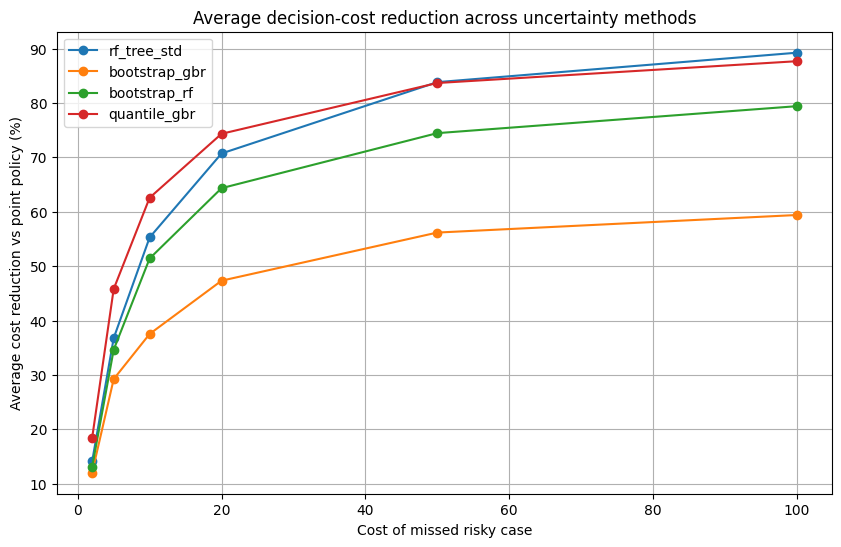

In [52]:
plt.figure(figsize=(10, 6))

for method in all_methods["method"].unique():
    subset = (
        all_methods[all_methods["method"] == method]
        .groupby("cost_fn")["cost_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["cost_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average cost reduction vs point policy (%)")
plt.title("Average decision-cost reduction across uncertainty methods")
plt.legend()
plt.grid(True)

plt.savefig(
    METHOD_COMPARE_DIR / "final_avg_cost_reduction_all_methods.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

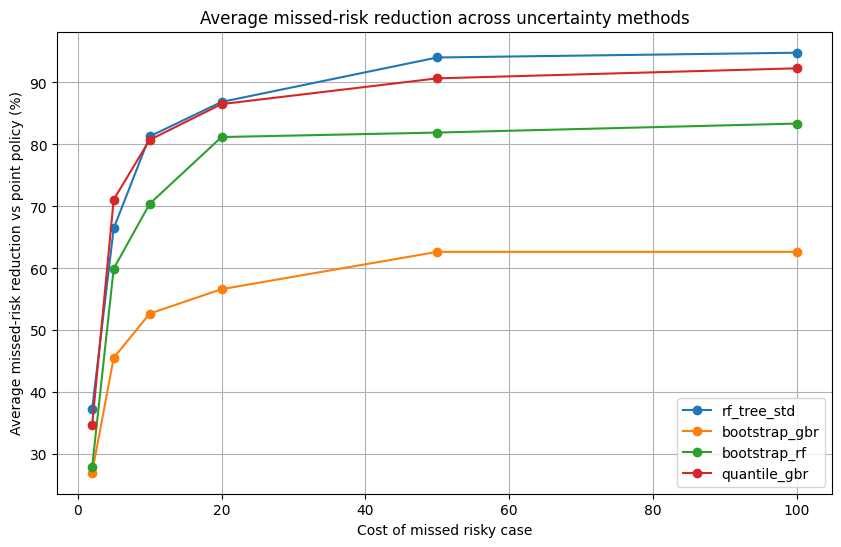

In [53]:
plt.figure(figsize=(10, 6))

for method in all_methods["method"].unique():
    subset = (
        all_methods[all_methods["method"] == method]
        .groupby("cost_fn")["fn_reduction_percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        subset["cost_fn"],
        subset["fn_reduction_percent"],
        marker="o",
        label=method,
    )

plt.xlabel("Cost of missed risky case")
plt.ylabel("Average missed-risk reduction vs point policy (%)")
plt.title("Average missed-risk reduction across uncertainty methods")
plt.legend()
plt.grid(True)

plt.savefig(
    METHOD_COMPARE_DIR / "final_avg_fn_reduction_all_methods.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [54]:
absolute_cost_ranking_cost20 = (
    final_method_table[final_method_table["cost_fn"] == 20]
    .sort_values(["dataset", "uncertainty_eval_total_cost"])
    [
        [
            "dataset",
            "method",
            "best_k_chosen_on_calibration",
            "uncertainty_eval_FN",
            "uncertainty_eval_total_cost",
            "fn_reduction_percent",
            "cost_reduction_percent",
        ]
    ]
)

absolute_cost_ranking_cost20.to_csv(
    METHOD_COMPARE_DIR / "absolute_cost_ranking_cost_fn_20.csv",
    index=False,
)

absolute_cost_ranking_cost20

,dataset,method,best_k_chosen_on_calibration,uncertainty_eval_FN,uncertainty_eval_total_cost,fn_reduction_percent,cost_reduction_percent
3,FD001,rf_tree_std,1.05,9.0,410.0,85.245902,67.563291
75,FD001,quantile_gbr,0.85,11.0,414.0,81.967213,67.427223
27,FD001,bootstrap_gbr,2.60,21.0,573.0,69.117647,59.275053
51,FD001,bootstrap_rf,3.60,13.0,588.0,77.586207,51.162791
9,FD002,rf_tree_std,1.55,53.0,2985.0,91.423948,76.068308
81,FD002,quantile_gbr,1.25,49.0,3162.0,94.295693,81.690793
57,FD002,bootstrap_rf,6.00,106.0,3741.0,83.411581,70.943689
33,FD002,bootstrap_gbr,6.00,603.0,12460.0,32.625698,30.666073
15,FD003,rf_tree_std,1.45,9.0,495.0,88.750000,69.761759
87,FD003,quantile_gbr,1.25,14.0,495.0,83.529412,71.906924


In [55]:
absolute_avg_summary = (
    final_method_table
    .groupby(["method", "cost_fn"])
    .agg(
        avg_uncertainty_eval_total_cost=("uncertainty_eval_total_cost", "mean"),
        avg_uncertainty_eval_FN=("uncertainty_eval_FN", "mean"),
        avg_cost_reduction_percent=("cost_reduction_percent", "mean"),
        avg_fn_reduction_percent=("fn_reduction_percent", "mean"),
    )
    .reset_index()
)

absolute_avg_summary.to_csv(
    METHOD_COMPARE_DIR / "absolute_average_method_summary_final.csv",
    index=False,
)

absolute_avg_summary

,method,cost_fn,avg_uncertainty_eval_total_cost,avg_uncertainty_eval_FN,avg_cost_reduction_percent,avg_fn_reduction_percent
0,bootstrap_gbr,2,863.25,314.75,12.019151,27.028654
1,bootstrap_gbr,5,1765.50,299.25,29.233010,45.573584
2,bootstrap_gbr,10,3258.00,294.00,37.528534,52.702645
3,bootstrap_gbr,20,6162.75,291.25,47.319297,56.646037
4,bootstrap_gbr,50,14782.50,287.00,56.167041,62.669406
5,bootstrap_gbr,100,29132.50,287.00,59.394153,62.669406
6,bootstrap_rf,2,638.00,209.75,13.062583,27.922012
7,bootstrap_rf,5,1090.75,126.00,34.636575,59.962027
8,bootstrap_rf,10,1572.50,84.00,51.405838,70.416901
9,bootstrap_rf,20,2268.25,66.50,64.327602,81.194787
